# Options Pricing & Risk Engine

This notebook is the **end-to-end explanation** of the project. The goal is not only to run the code, but to explain the quantitative logic behind each block:

1. **Market data**: download prices and transform them into returns.
2. **Volatility engine**: estimate volatility using flat historical volatility, EWMA and GARCH(1,1).
3. **Black-Scholes pricing**: price European call and put options using the selected volatility input.
4. **Greeks**: measure how sensitive the option price is to spot price, volatility, time and rates.
5. **Monte Carlo verification**: price the same option numerically through simulated future scenarios.
6. **Risk engine**: compute VaR and CVaR / Expected Shortfall using historical, parametric and Monte Carlo methods.

The central idea is that these are not isolated exercises. They form one coherent pipeline:

$$
\text{market data} \rightarrow \text{returns} \rightarrow \text{volatility} \rightarrow \text{pricing} \rightarrow \text{sensitivities} \rightarrow \text{risk}
$$

### Why this project exists

This is a self-study project built to get started in quantitative finance: an AI student's first hands-on attempt at connecting option pricing theory (Black-Scholes), numerical verification (Monte Carlo), time-varying volatility modeling (EWMA/GARCH) and risk measurement (VaR/CVaR) into one working pipeline, rather than learning each topic in isolation.

## Project interpretation

This project can be presented as a small **quantitative options pricing and risk engine**.

A basic Black-Scholes notebook would only compute a formula. This project goes further:

- it estimates volatility from real market data;
- compares several volatility assumptions;
- feeds those volatility estimates into Black-Scholes;
- checks the analytical price against Monte Carlo simulation;
- computes Greeks to understand sensitivities;
- uses the same distributional logic to estimate downside risk.

That is the key narrative for GitHub or a portfolio: **pricing, sensitivity and risk are connected**.


## 0. Imports and configuration

The source code lives inside `src/`, while this notebook lives inside `notebooks/`. The next cell adds the project source directory to the Python path so the modules can be imported cleanly.

The chosen default ticker is `SPY` because it is liquid, diversified and commonly used as a market benchmark. You can change it to `AAPL`, `NVDA`, `TSLA`, `QQQ`, etc.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from volatility.data import fetch_log_returns, fetch_spot_price
from volatility.ewma import ewma_volatility, latest_ewma_vol
from volatility.garch import fit_garch, garch_forecast_vol

from black_scholes.pricing import call_price, put_price
from black_scholes.greeks import (
    delta_call,
    delta_put,
    gamma,
    vega,
    theta_call,
    theta_put,
    rho_call,
    rho_put,
)

from monte_carlo.pricing import mc_call_price, mc_put_price
from monte_carlo.simulation import simulate_terminal_prices

from var.historical import historical_var, historical_cvar
from var.parametric import parametric_var, parametric_cvar
from var.monte_carlo import mc_var, mc_cvar

TICKER = "SPY"
PERIOD = "2y"
TRADING_DAYS = 252
SEED = 42


# 1. Market data and returns

Option pricing and risk models usually work with **returns**, not raw prices. Prices are non-stationary and depend heavily on the nominal level of the asset. Returns measure relative movement.

This notebook uses **daily log returns**:

$$
r_t = \log\left(\frac{S_t}{S_{t-1}}\right)
$$

Log returns are useful because they are approximately additive over time:

$$
r_{1,T} \approx r_1 + r_2 + \cdots + r_T
$$

This matters later when we annualize volatility and simulate future scenarios.


In [2]:
returns = fetch_log_returns(TICKER, period=PERIOD)
S = fetch_spot_price(TICKER)
r_arr = returns.values

summary = pd.DataFrame(
    {
        "value": [
            TICKER,
            len(returns),
            returns.index.min().date(),
            returns.index.max().date(),
            S,
            returns.mean(),
            returns.std(ddof=1),
            returns.std(ddof=1) * np.sqrt(TRADING_DAYS),
        ]
    },
    index=[
        "ticker",
        "number of daily returns",
        "first date",
        "last date",
        "latest spot price",
        "mean daily log return",
        "daily volatility",
        "annualized volatility",
    ],
)

display(summary)


,value
ticker,SPY
number of daily returns,500
first date,2024-07-05
last date,2026-07-02
latest spot price,744.780029
mean daily log return,0.000648
daily volatility,0.01067
annualized volatility,0.169381


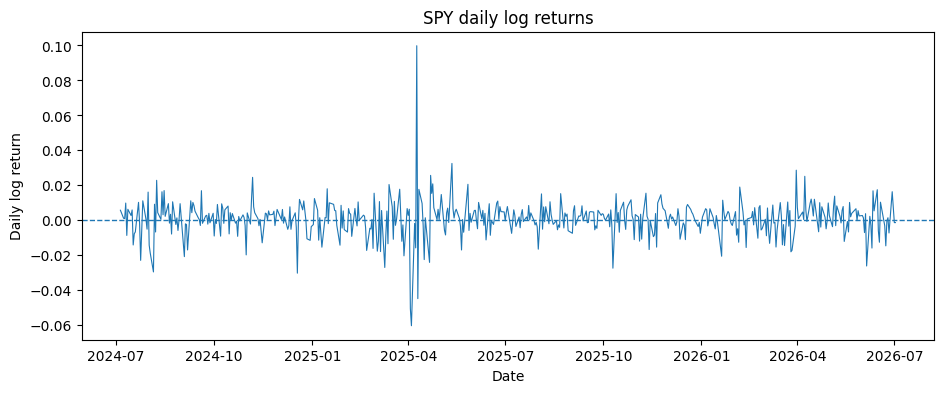

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(returns.index, returns.values, linewidth=0.8)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(f"{TICKER} daily log returns")
ax.set_xlabel("Date")
ax.set_ylabel("Daily log return")
plt.show()


## Interpretation

The returns plot is usually noisy. That is normal: daily financial returns contain a large random component. What matters for this project is not predicting every daily movement, but extracting a volatility estimate that can be used for pricing and risk.

The most important input from this section is the return series $r_t$, because it feeds the volatility models and the historical VaR calculation.


# 2. Volatility modeling

Black-Scholes needs a volatility input $\sigma$. The simplest choice is flat historical volatility:

$$
\sigma_{hist} = \text{std}(r_t) \sqrt{252}
$$

But market volatility is not constant. Periods of high volatility tend to be followed by high volatility, and calm periods tend to persist. This is called **volatility clustering**.

This notebook compares three volatility estimates:

1. **Flat historical volatility**: one constant volatility number.
2. **EWMA volatility**: recent returns receive more weight than old returns.
3. **GARCH(1,1)**: a time-series model designed to capture volatility clustering.


## 2.1 Flat historical volatility

Flat historical volatility is useful as a baseline, but it assumes that the full historical sample is equally relevant today. That can be too naive if the market recently became much more or less volatile.


In [4]:
flat_vol = r_arr.std(ddof=1) * np.sqrt(TRADING_DAYS)
print(f"Flat historical annualized volatility: {flat_vol:.2%}")


Flat historical annualized volatility: 16.94%


## 2.2 EWMA volatility

EWMA stands for **Exponentially Weighted Moving Average**. The RiskMetrics-style recursion is:

$$
\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2
$$

The parameter $\lambda$ controls memory. A common value is $\lambda=0.94$ for daily returns. A high $\lambda$ means volatility changes slowly; a lower $\lambda$ reacts faster to new shocks.


In [5]:
ewma_daily = ewma_volatility(r_arr, lam=0.94)
ewma_series = ewma_daily * np.sqrt(TRADING_DAYS)
ewma_vol = ewma_series[-1]

print(f"Latest EWMA annualized volatility: {ewma_vol:.2%}")


Latest EWMA annualized volatility: 15.35%


## 2.3 GARCH(1,1) volatility

A GARCH(1,1) model estimates conditional volatility using both past shocks and past volatility:

$$
\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2
$$

The intuition:

- $\alpha$ measures how much volatility reacts to recent shocks;
- $\beta$ measures how persistent volatility is;
- $\omega$ is the long-run variance component.

This is useful because volatility is itself dynamic. For options, a better volatility estimate can materially change the theoretical price.


In [6]:
garch_result = fit_garch(r_arr)
garch_vol = garch_forecast_vol(garch_result, horizon=1)

print(f"GARCH(1,1) one-day-ahead annualized volatility forecast: {garch_vol:.2%}")


GARCH(1,1) one-day-ahead annualized volatility forecast: 14.16%


In [7]:
vol_table = pd.DataFrame(
    {
        "annualized_volatility": [flat_vol, ewma_vol, garch_vol],
        "interpretation": [
            "constant baseline estimated from the whole sample",
            "latest volatility estimate with more weight on recent returns",
            "one-step-ahead conditional volatility forecast",
        ],
    },
    index=["Flat historical", "EWMA", "GARCH(1,1)"],
)

vol_table["annualized_volatility_%"] = vol_table["annualized_volatility"].map(lambda x: f"{x:.2%}")
display(vol_table[["annualized_volatility_%", "interpretation"]])


,annualized_volatility_%,interpretation
Flat historical,16.94%,constant baseline estimated from the whole sample
EWMA,15.35%,latest volatility estimate with more weight on...
"GARCH(1,1)",14.16%,one-step-ahead conditional volatility forecast


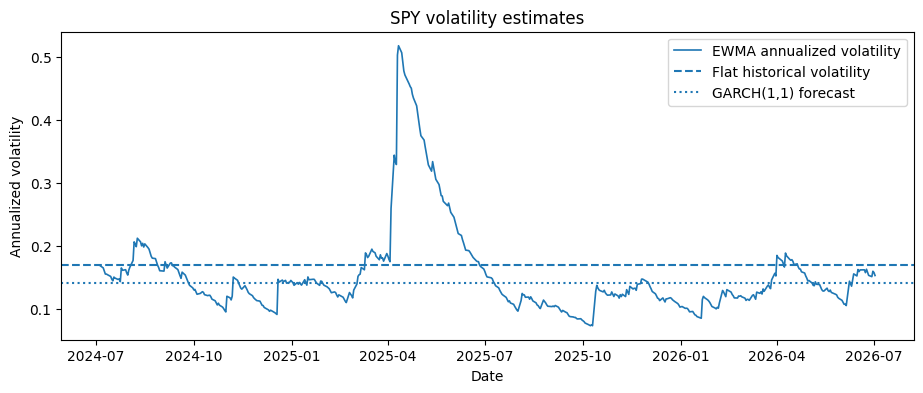

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(returns.index, ewma_series, label="EWMA annualized volatility", linewidth=1.2)
ax.axhline(flat_vol, linestyle="--", label="Flat historical volatility")
ax.axhline(garch_vol, linestyle=":", label="GARCH(1,1) forecast")
ax.set_title(f"{TICKER} volatility estimates")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
ax.legend()
plt.show()


## Volatility takeaway

The project now has three candidate values for $\sigma$. In the pricing section, we can compare how sensitive the option price is to the volatility assumption.

This matters because volatility is often the most important input in option pricing. A small change in $\sigma$ can lead to a large change in the price of an option, especially when time to maturity is long or the option has high Vega.


# 3. Black-Scholes option pricing

Black-Scholes gives a closed-form price for a European call or put option under specific assumptions.

For a European call:

$$
C = S_0N(d_1) - Ke^{-rT}N(d_2)
$$

For a European put:

$$
P = Ke^{-rT}N(-d_2) - S_0N(-d_1)
$$

with:

$$
d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

where:

- $S_0$: current spot price;
- $K$: strike price;
- $T$: time to maturity in years;
- $r$: risk-free rate;
- $\sigma$: annualized volatility;
- $N(\cdot)$: standard normal CDF.


## Option setup

We use a simple at-the-money 30-day European option. This keeps the interpretation clean:

- `K = round(S)` makes the strike close to the current spot;
- `T = 30/365` means approximately one month to expiration;
- `r = 0.05` is a simplified annual risk-free rate assumption.

In a production-quality project, the risk-free rate would be pulled from a yield curve or treasury data source. Here it is fixed so the focus stays on the pricing pipeline.


In [9]:
K = round(S)
T = 30 / 365
r = 0.05

option_inputs = pd.DataFrame(
    {"value": [S, K, T, r]},
    index=["Spot price S", "Strike K", "Time to maturity T", "Risk-free rate r"],
)
display(option_inputs)


,value
Spot price S,744.780029
Strike K,745.000000
Time to maturity T,0.082192
Risk-free rate r,0.050000


## Price comparison under different volatility assumptions

The next table prices the same option using three volatility inputs. This is one of the most important comparisons in the notebook: the model is the same, but the volatility assumption changes.


In [10]:
vol_inputs = {
    "Flat historical": flat_vol,
    "EWMA": ewma_vol,
    "GARCH(1,1)": garch_vol,
}

pricing_rows = []
for name, sigma in vol_inputs.items():
    pricing_rows.append(
        {
            "volatility_model": name,
            "sigma": sigma,
            "call_price": call_price(S, K, T, r, sigma),
            "put_price": put_price(S, K, T, r, sigma),
        }
    )

pricing_table = pd.DataFrame(pricing_rows).set_index("volatility_model")
pricing_table["sigma_%"] = pricing_table["sigma"].map(lambda x: f"{x:.2%}")
display(pricing_table[["sigma_%", "call_price", "put_price"]])


,sigma_%,call_price,put_price
volatility_model,,,
Flat historical,16.94%,15.861578,13.026187
EWMA,15.35%,14.515883,11.680492
"GARCH(1,1)",14.16%,13.509866,10.674475


## Pricing interpretation

Higher volatility generally increases both call and put prices. The reason is that an option has asymmetric payoff:

- the downside for the option buyer is limited to the premium;
- the upside can become large if the underlying moves favorably.

Therefore, more uncertainty increases the value of optionality.

For the rest of the notebook, we use the GARCH volatility forecast as the main $\sigma$, because it is the most model-based estimate of current conditional volatility.


In [11]:
sigma = garch_vol
c_price = call_price(S, K, T, r, sigma)
p_price = put_price(S, K, T, r, sigma)

print(f"Selected sigma: {sigma:.2%}")
print(f"Black-Scholes call price: {c_price:.4f}")
print(f"Black-Scholes put price:  {p_price:.4f}")


Selected sigma: 14.16%
Black-Scholes call price: 13.5099
Black-Scholes put price:  10.6745


# 4. Greeks: option sensitivities

The price alone is not enough. Options are managed through their **sensitivities**, known as Greeks.

Main Greeks:

- **Delta**: sensitivity to the underlying price $S$.
- **Gamma**: sensitivity of Delta to $S$.
- **Vega**: sensitivity to volatility $\sigma$.
- **Theta**: sensitivity to time decay.
- **Rho**: sensitivity to the interest rate $r$.

In a trading or risk context, Greeks answer: **where is the risk coming from?**


In [12]:
greeks_table = pd.DataFrame(
    {
        "Call": [
            delta_call(S, K, T, r, sigma),
            gamma(S, K, T, r, sigma),
            vega(S, K, T, r, sigma),
            theta_call(S, K, T, r, sigma),
            rho_call(S, K, T, r, sigma),
        ],
        "Put": [
            delta_put(S, K, T, r, sigma),
            gamma(S, K, T, r, sigma),
            vega(S, K, T, r, sigma),
            theta_put(S, K, T, r, sigma),
            rho_put(S, K, T, r, sigma),
        ],
        "Meaning": [
            "Sensitivity to spot price",
            "Sensitivity of Delta to spot price",
            "Sensitivity to volatility; raw value per 1.00 change in sigma",
            "Sensitivity to time; raw value per year",
            "Sensitivity to interest rate; raw value per 1.00 change in r",
        ],
    },
    index=["Delta", "Gamma", "Vega", "Theta", "Rho"],
)

display(greeks_table)


,Call,Put,Meaning
Delta,0.545480,-0.454520,Sensitivity to spot price
Gamma,0.013108,0.013108,Sensitivity of Delta to spot price
Vega,84.628733,84.628733,Sensitivity to volatility; raw value per 1.00 ...
Theta,-92.542746,-55.445514,Sensitivity to time; raw value per year
Rho,32.281062,-28.700689,Sensitivity to interest rate; raw value per 1....


## Interpreting the Greeks

A few useful rules:

- A call Delta is usually between 0 and 1. A Delta of 0.55 means the call moves roughly 0.55 for a 1-unit move in the underlying.
- A put Delta is usually between -1 and 0.
- Gamma is highest around the strike for short-dated at-the-money options.
- Vega is usually high when the option has meaningful time value.
- Theta is often negative for long options because time decay hurts the option buyer.

The next plots show how Delta, Gamma and Vega change when the spot price changes while the other inputs remain fixed.


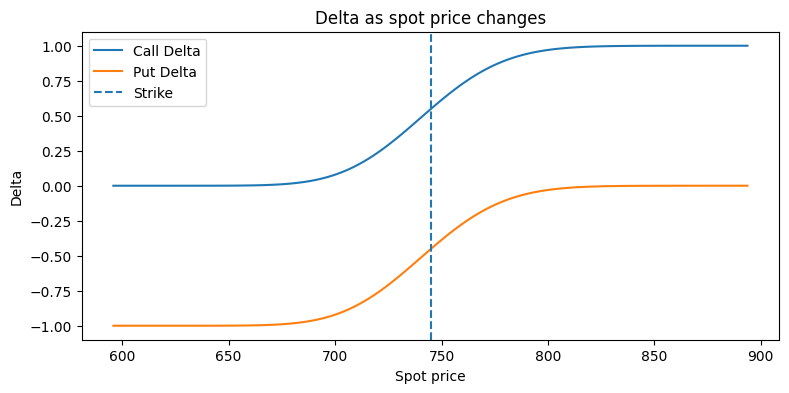

In [13]:
S_range = np.linspace(S * 0.8, S * 1.2, 120)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(S_range, [delta_call(s, K, T, r, sigma) for s in S_range], label="Call Delta")
ax.plot(S_range, [delta_put(s, K, T, r, sigma) for s in S_range], label="Put Delta")
ax.axvline(K, linestyle="--", label="Strike")
ax.set_title("Delta as spot price changes")
ax.set_xlabel("Spot price")
ax.set_ylabel("Delta")
ax.legend()
plt.show()


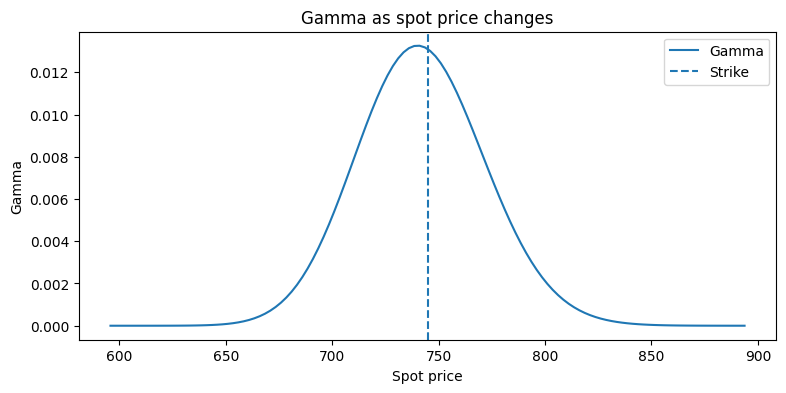

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(S_range, [gamma(s, K, T, r, sigma) for s in S_range], label="Gamma")
ax.axvline(K, linestyle="--", label="Strike")
ax.set_title("Gamma as spot price changes")
ax.set_xlabel("Spot price")
ax.set_ylabel("Gamma")
ax.legend()
plt.show()


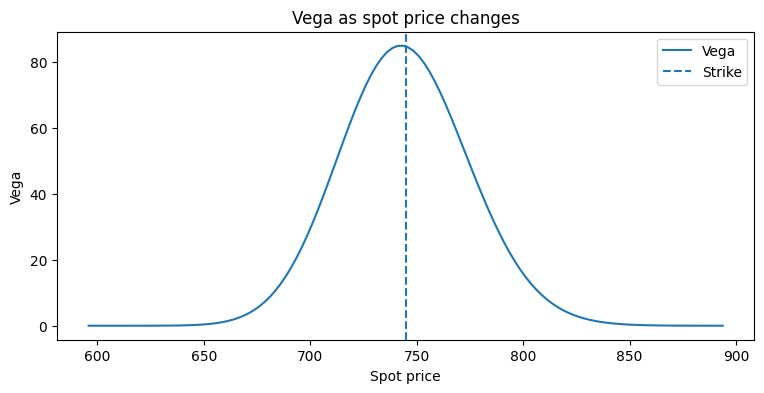

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(S_range, [vega(s, K, T, r, sigma) for s in S_range], label="Vega")
ax.axvline(K, linestyle="--", label="Strike")
ax.set_title("Vega as spot price changes")
ax.set_xlabel("Spot price")
ax.set_ylabel("Vega")
ax.legend()
plt.show()


# 5. Monte Carlo pricing verification

Black-Scholes gives an analytical solution. Monte Carlo estimates the option price numerically by simulating many possible future prices.

Under risk-neutral geometric Brownian motion:

$$
S_T = S_0 \exp\left((r - \frac{1}{2}\sigma^2)T + \sigma\sqrt{T}Z\right), \quad Z \sim N(0,1)
$$

For a call option:

$$
C \approx e^{-rT}\frac{1}{N}\sum_{i=1}^{N}\max(S_T^{(i)} - K, 0)
$$

For a put option:

$$
P \approx e^{-rT}\frac{1}{N}\sum_{i=1}^{N}\max(K - S_T^{(i)}, 0)
$$

If the assumptions are the same, the Monte Carlo price should converge toward the Black-Scholes price as the number of simulations grows.


In [16]:
n_sims_list = [100, 1_000, 10_000, 100_000, 500_000]
mc_call_results = [mc_call_price(S, K, T, r, sigma, n, seed=SEED) for n in n_sims_list]
mc_put_results = [mc_put_price(S, K, T, r, sigma, n, seed=SEED) for n in n_sims_list]

mc_table = pd.DataFrame(
    {
        "n_sims": n_sims_list,
        "mc_call_price": [m.price for m in mc_call_results],
        "call_std_error": [m.std_error for m in mc_call_results],
        "call_ci_low": [m.ci_low for m in mc_call_results],
        "call_ci_high": [m.ci_high for m in mc_call_results],
        "mc_put_price": [m.price for m in mc_put_results],
        "put_std_error": [m.std_error for m in mc_put_results],
    }
)
mc_table["call_abs_error_vs_bs"] = (mc_table["mc_call_price"] - c_price).abs()
mc_table["put_abs_error_vs_bs"] = (mc_table["mc_put_price"] - p_price).abs()

display(mc_table)


,n_sims,mc_call_price,call_std_error,call_ci_low,call_ci_high,mc_put_price,put_std_error,call_abs_error_vs_bs,put_abs_error_vs_bs
0,100,10.186617,1.341757,7.556772,12.816461,9.116911,1.338248,3.323249,1.557564
1,1000,12.802785,0.581055,11.663916,13.941653,10.854573,0.525286,0.707081,0.180098
2,10000,13.357786,0.190721,12.983973,13.731600,10.824544,0.165194,0.152079,0.150069
3,100000,13.462632,0.060419,13.344212,13.581052,10.750609,0.051702,0.047234,0.076134
4,500000,13.507490,0.026955,13.454658,13.560321,10.686408,0.023006,0.002376,0.011933


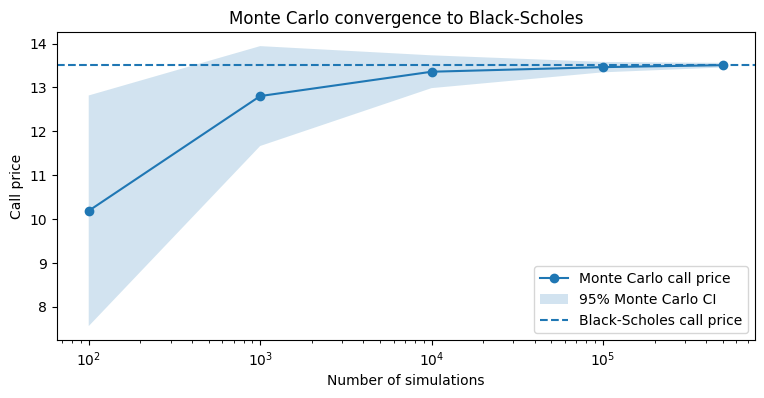

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mc_table["n_sims"], mc_table["mc_call_price"], marker="o", label="Monte Carlo call price")
ax.fill_between(
    mc_table["n_sims"],
    mc_table["call_ci_low"],
    mc_table["call_ci_high"],
    alpha=0.2,
    label="95% Monte Carlo CI",
)
ax.axhline(c_price, linestyle="--", label="Black-Scholes call price")
ax.set_xscale("log")
ax.set_xlabel("Number of simulations")
ax.set_ylabel("Call price")
ax.set_title("Monte Carlo convergence to Black-Scholes")
ax.legend()
plt.show()


## Monte Carlo interpretation

With few simulations, the Monte Carlo estimate can be noisy. As the number of simulations increases, the standard error decreases approximately at rate:

$$
\frac{1}{\sqrt{N}}
$$

This is why Monte Carlo can be computationally expensive: reducing the error by a factor of 10 requires roughly 100 times more simulations.

For this simple European option, Black-Scholes is faster and exact under its assumptions. Monte Carlo becomes more useful for path-dependent or more complex instruments where no closed-form formula is available.


# 6. Simulated terminal distribution

Monte Carlo also gives a full distribution of possible terminal prices, not just one price estimate. This is useful for understanding uncertainty.


In [18]:
S_T = simulate_terminal_prices(S, T, r, sigma, n_sims=100_000, seed=SEED)
terminal_returns = S_T / S - 1

terminal_summary = pd.Series(
    {
        "mean terminal price": S_T.mean(),
        "median terminal price": np.median(S_T),
        "5% terminal price": np.percentile(S_T, 5),
        "95% terminal price": np.percentile(S_T, 95),
        "probability terminal price < strike": np.mean(S_T < K),
    }
)

display(terminal_summary.to_frame("value"))


,value
mean terminal price,747.723191
median terminal price,746.957905
5% terminal price,698.578514
95% terminal price,798.887352
probability terminal price < strike,0.473020


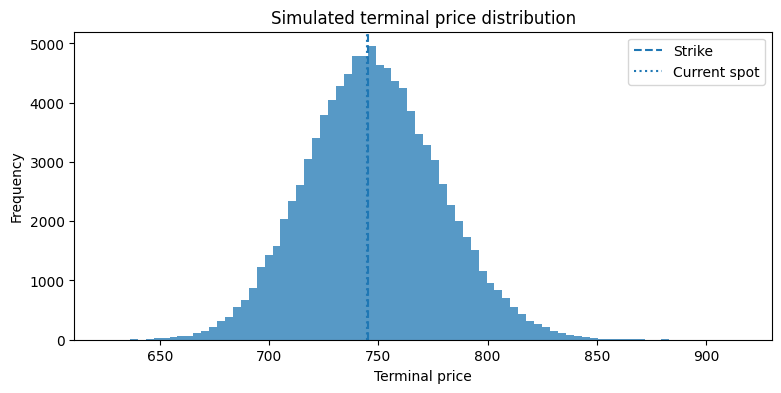

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(S_T, bins=80, alpha=0.75)
ax.axvline(K, linestyle="--", label="Strike")
ax.axvline(S, linestyle=":", label="Current spot")
ax.set_title("Simulated terminal price distribution")
ax.set_xlabel("Terminal price")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()


# 7. VaR and CVaR / Expected Shortfall

Value at Risk answers:

> At a given confidence level, what is the maximum loss we expect not to exceed over a given horizon?

For example, a 95% one-day VaR of 2% means:

> Under the model, 95% of days should lose less than 2%; the worst 5% of days can lose more.

CVaR, also called Expected Shortfall, asks a more severe question:

> If we are in the tail beyond VaR, what is the average loss?

This makes CVaR more informative about tail risk.


## VaR methods used

This notebook compares three methods:

1. **Historical VaR**: reads the empirical percentile from past returns.
2. **Parametric VaR**: assumes returns are normally distributed.
3. **Monte Carlo VaR**: simulates future returns using the same GBM engine used for option pricing.

Each method has different assumptions. Comparing them is more informative than reporting a single number.


In [20]:
confidence = 0.95
portfolio_value = 10_000

risk_methods = {
    "Historical": (
        historical_var(r_arr, confidence),
        historical_cvar(r_arr, confidence),
        historical_var(r_arr, confidence, portfolio_value),
        historical_cvar(r_arr, confidence, portfolio_value),
    ),
    "Parametric": (
        parametric_var(r_arr, confidence),
        parametric_cvar(r_arr, confidence),
        parametric_var(r_arr, confidence, portfolio_value),
        parametric_cvar(r_arr, confidence, portfolio_value),
    ),
    "Monte Carlo": (
        mc_var(S, 1 / TRADING_DAYS, r, sigma, confidence=confidence, n_sims=200_000, seed=SEED),
        mc_cvar(S, 1 / TRADING_DAYS, r, sigma, confidence=confidence, n_sims=200_000, seed=SEED),
        mc_var(S, 1 / TRADING_DAYS, r, sigma, confidence=confidence, n_sims=200_000, seed=SEED, portfolio_value=portfolio_value),
        mc_cvar(S, 1 / TRADING_DAYS, r, sigma, confidence=confidence, n_sims=200_000, seed=SEED, portfolio_value=portfolio_value),
    ),
}

risk_table = pd.DataFrame.from_dict(
    risk_methods,
    orient="index",
    columns=["VaR fraction", "CVaR fraction", "VaR amount", "CVaR amount"],
)

risk_table["VaR %"] = risk_table["VaR fraction"].map(lambda x: f"{x:.2%}")
risk_table["CVaR %"] = risk_table["CVaR fraction"].map(lambda x: f"{x:.2%}")
risk_table["VaR amount"] = risk_table["VaR amount"].map(lambda x: f"${x:,.2f}")
risk_table["CVaR amount"] = risk_table["CVaR amount"].map(lambda x: f"${x:,.2f}")

display(risk_table[["VaR %", "CVaR %", "VaR amount", "CVaR amount"]])


,VaR %,CVaR %,VaR amount,CVaR amount
Historical,1.61%,2.48%,$161.12,$248.44
Parametric,1.69%,2.14%,$169.03,$213.61
Monte Carlo,1.45%,1.81%,$144.65,$180.88


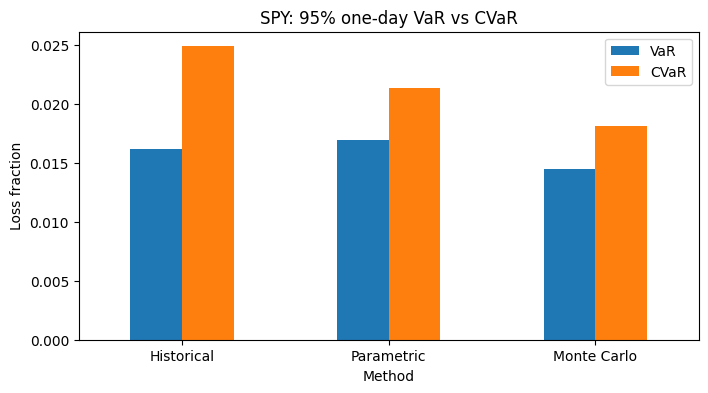

In [21]:
plot_table = pd.DataFrame.from_dict(
    {k: {"VaR": v[0], "CVaR": v[1]} for k, v in risk_methods.items()},
    orient="index",
)

fig, ax = plt.subplots(figsize=(8, 4))
plot_table.plot(kind="bar", ax=ax)
ax.set_title(f"{TICKER}: {int(confidence*100)}% one-day VaR vs CVaR")
ax.set_ylabel("Loss fraction")
ax.set_xlabel("Method")
ax.tick_params(axis="x", rotation=0)
plt.show()


## VaR interpretation

The comparison is useful because each method makes a different assumption:

- Historical VaR assumes the recent past is representative of the near future.
- Parametric VaR assumes returns are approximately normal.
- Monte Carlo VaR assumes the simulated GBM dynamics are a reasonable approximation.

CVaR should usually be larger than VaR, because it measures the average loss inside the tail, not just the threshold.


# 8. Final project summary

This notebook connects the full project:

1. **Returns** are extracted from market prices.
2. **Volatility** is estimated using historical, EWMA and GARCH methods.
3. **Black-Scholes** uses volatility to price European options.
4. **Greeks** explain how the option price reacts to changes in market variables.
5. **Monte Carlo** verifies the analytical price through simulation.
6. **VaR and CVaR** quantify downside risk using historical, parametric and simulated distributions.

The main lesson is that pricing and risk are not separate topics. They are both ways of modeling uncertainty.


# 9. Limitations and possible extensions

## Limitations

This is an educational project, not a production trading system. Important limitations:

- Black-Scholes assumes constant volatility and continuous trading.
- The option is European and does not include dividends explicitly.
- GARCH is fitted on historical returns and may not match implied volatility from the options market.
- VaR does not describe how bad losses can get beyond the threshold; CVaR helps, but still depends on assumptions.
- The risk-free rate is fixed manually.
- Transaction costs, bid-ask spread and liquidity are ignored.

## Strong extensions

Good next steps:

1. Add **implied volatility** by inverting Black-Scholes from market option prices.
2. Add **put-call parity checks** inside the notebook.
3. Add **numerical Greeks** using finite differences and compare them to analytical Greeks.
4. Add **Expected Shortfall plots** and tail diagnostics.
5. Compare GARCH volatility with actual implied volatility.
6. Build a small dashboard or CLI that prices options from user inputs.
7. Add a second notebook for **Financial ML Signal Research** using volatility and VaR features.
